In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
raw_wine = pd.read_csv('winequality-red.csv')
wine = raw_wine.copy()

In [4]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df_corr = wine.corr()
df_corr['quality'].drop('quality').sort_values(ascending=False)

alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

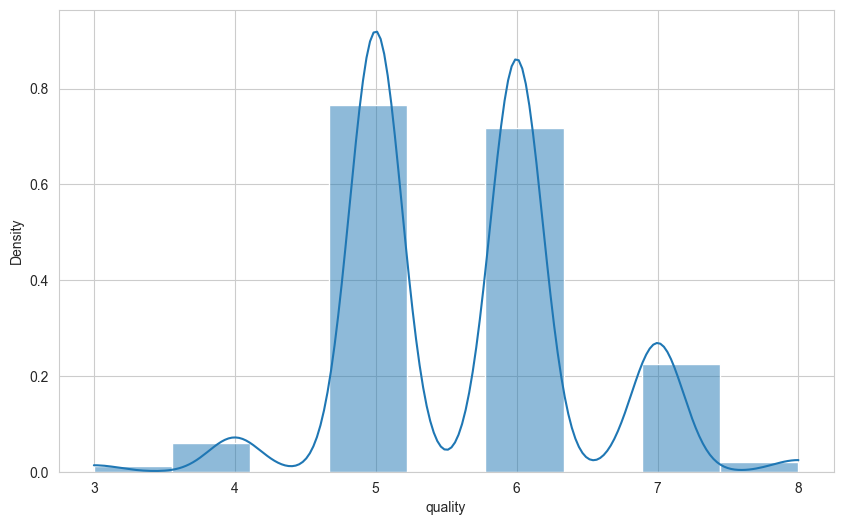

In [7]:
fig = plt.figure(figsize=(10,6))
sns.histplot(x='quality', data=wine, kde=True, stat='density', bins=9);

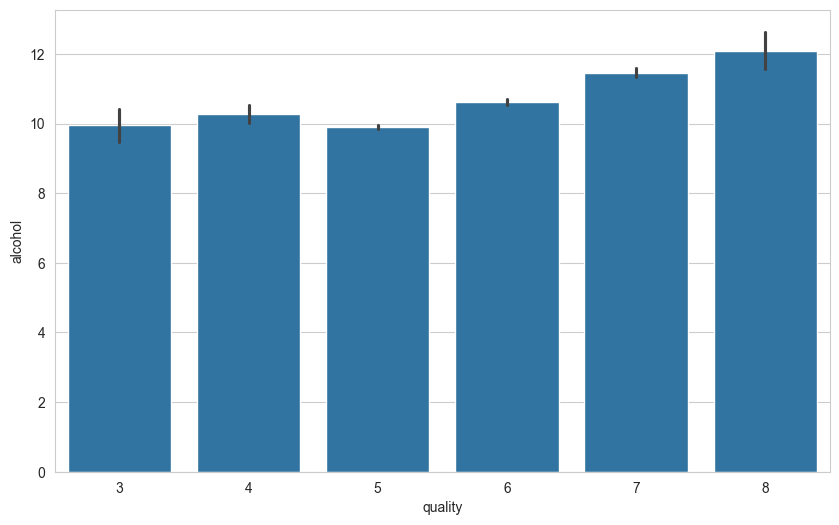

In [8]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x = 'quality', y = 'alcohol', data = wine);

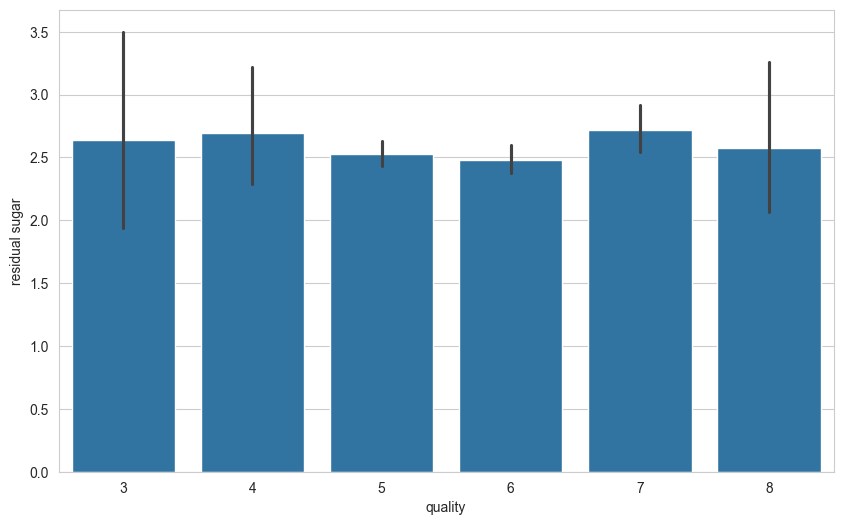

In [9]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x = 'quality', y = 'residual sugar', data = wine);

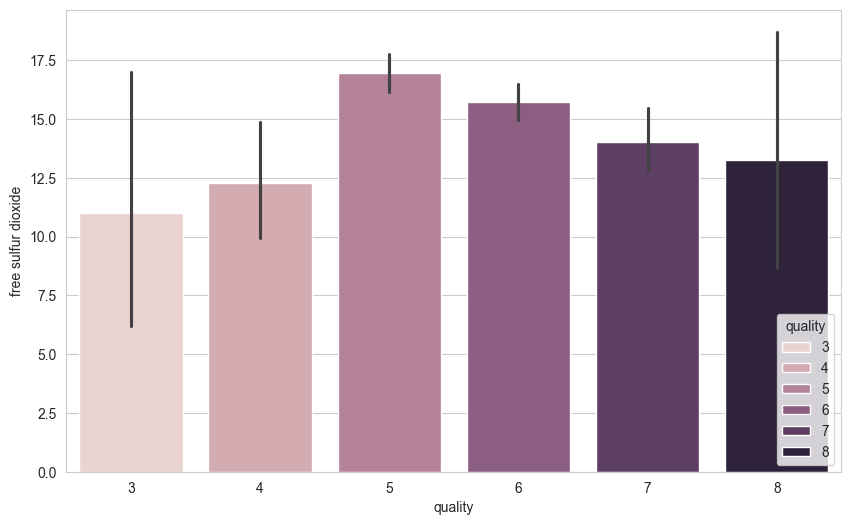

In [10]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x = 'quality', y = 'free sulfur dioxide', data = wine, hue = 'quality');

In [11]:
bins = (2, 6.5, 8)
group_names = ['low', 'high']
wine['quality'] = pd.cut(wine['quality'], bins = bins, labels = group_names)

In [12]:
from sklearn.preprocessing import LabelEncoder

label_quality = LabelEncoder()

In [13]:
wine['quality'] = label_quality.fit_transform(wine['quality'])

In [14]:
wine['quality'].value_counts(normalize=True)

quality
1    0.86429
0    0.13571
Name: proportion, dtype: float64

In [15]:
X = wine.drop('quality', axis=1)
y = wine['quality']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import numpy as np

lr = LogisticRegression(solver='liblinear', random_state=42)

param_grid = {
    'C': np.logspace(-3, 3, 10),
    'penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5
)

grid_search.fit(X_train_scaled, Y_train)

best_lr = grid_search.best_estimator_

Y_proba_best = best_lr.predict_proba(X_test_scaled)[:, 1]
Y_pred_best = best_lr.predict(X_test_scaled)

print(classification_report(Y_test, Y_pred_best))
print(confusion_matrix(Y_test, Y_pred_best))

              precision    recall  f1-score   support

           0       0.59      0.21      0.31        47
           1       0.88      0.97      0.92       273

    accuracy                           0.86       320
   macro avg       0.73      0.59      0.62       320
weighted avg       0.84      0.86      0.83       320

[[ 10  37]
 [  7 266]]


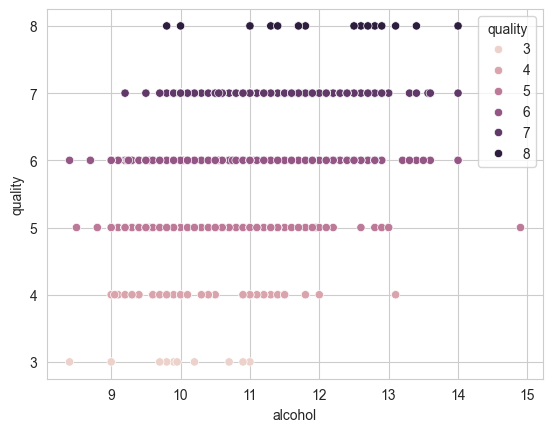

In [19]:
sns.scatterplot(x='alcohol', y='quality', data=raw_wine, hue='quality');

In [20]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svc = LinearSVC(random_state=42, max_iter=10000)
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-3, 3, 10)
}
grid_search_svc = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5
)

grid_search_svc.fit(X_train_scaled, Y_train)
best_svc = grid_search_svc.best_estimator_
Y_pred_svc = best_svc.predict(X_test_scaled)

print(classification_report(Y_test, Y_pred_svc))
print(confusion_matrix(Y_test, Y_pred_svc))

              precision    recall  f1-score   support

           0       0.67      0.13      0.21        47
           1       0.87      0.99      0.92       273

    accuracy                           0.86       320
   macro avg       0.77      0.56      0.57       320
weighted avg       0.84      0.86      0.82       320

[[  6  41]
 [  3 270]]


In [ ]:
from sklearn.decomposition import PCA
